# Модель для прогнозирования оттока клиентов для сервиса доставки кофе

### Описание исследования

На рынке доставки кофе высокая конкуренция, привлечение нового клиента обходится в 5–7 раз дороже, чем удержание существующего. В связи с этим к нам обратилась компания, для правильного распределения финансов которой необходимо реализовать проект по прогнозированию оттока клиентов.

### Цель исследования

Целью исследования является проведение анализа данных и построение модели бинарной классификации, которая позволила бы прогнозировать отток клиентов из сервиса по доставке кофе.

### Задачи исследования

Задачи исследования включают в себя следующие пункты:
- Исследовательский анализ данных (EDA);
- Предобработку данных;
- Обучение и оценку базовой модели;
- Создание и отбор новых признаков;
- Подбор гиперпараметров модели;
- Финальное обучение модели и подготовку артефактов.

### Постановка задачи машинного обучения

В рамках выполнения проекта необходимо построить модель бинарной классификации, которая спрогнозирует вероятность оттока каждого клиента сервиса с доставкой кофе в следующем месяце. 

Таким образом, выполняемая задача - задача бинарной классификации. Соответственно, тип задачи - обучение с учителем, так как обучение происходит по размеченным данным.

Целевой переменной является поле `churn`, которое отвечает за то, перестал ли пользователь пользоваться сервисом, где:
- значение `1` соответствует тому, что пользователь перестал пользоваться сервисом;
- значение `0` соответствует тому, что пользователь не перестал пользоваться сервисом.

В интересах компании -  эффективно расходовать бюджет, для чего подойдет использование комбинации метрик `Precision` и `Recall`. При этом так же важно, что в данных наблюдается дисбаланс классов - информации об уходящих с сервиса польователях горазде меньше, чем о тех, кто остается. Поэтому, в том числе чтобы не зависеть от порога классификации, адекватной и информативной метрикой для оценки качества модели может послужить Precision-Recall AUC (PR AUC). Она фокусируется на корректном предсказании меньшего по объёму, но ключевого для задачи класса — уходящих клиентов. При этом модель окажется полезной, если значение метрики PR AUC будет намного лучше, чем значение случайного классификатора, которое для этой метрики равно доле положительного класса.

Подводя итог, для измерения качества модели будут использоваться метрики PR AUC, а также log loss - данная метрика являеся основной метрикой качества, на которой базируется обучение логистической регрессии.  

### Содержимое проекта

1. [Подготовка среды и библиотек.](#1-bullet)
2. [Предобработка данных.](#2-bullet)<br>
    2.1 [Задача 1](#2.1-bullet)<br>
    2.2 [Задача 2](#2.2-bullet)<br>
    2.3 [Задача 3](#2.3-bullet)<br>
    2.4 [Задача 4](#2.4-bullet)<br>
    2.5 [Задача 5](#2.5-bullet)<br>
    2.6 [Задача 6](#2.6-bullet)<br>
    2.7 [Задача 7](#2.7-bullet)<br>
    2.8 [Задача 8](#2.8-bullet)<br>
3. [Предобработка данных](#3-bullet)<br>
4. [Обучение модели](#4-bullet)<br>
5. [Создание новых признаков](#5-bullet)<br>
6. [Эксперименты с гиперпараметрами](#6-bullet)<br>
7. [Подготовка финальной модели](#7-bullet)<br>
8. [Отчёт о проделанной работе](#8-bullet)<br>
9. [Сохранение модели для продакшена](#9-bullet)<br>
---

<a class="anchor" id="1-bullet"></a>
## Этап 1. Подготовка среды и библиотек

Импортируем библиотеки.

In [1]:
import numpy as np
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import TargetEncoder, StandardScaler, FunctionTransformer
import seaborn as sns
from phik import phik_matrix
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import log_loss, average_precision_score
from sklearn.linear_model import LogisticRegression

Зафиксируем `random_state`.

In [2]:
np.random.seed(42)

Загрузим данные.

In [3]:
try:
    df = pd.read_csv('/datasets/coffee_churn_dataset.csv', sep=',', decimal='.') 
except:
    df = pd.read_csv('https://code.s3.yandex.net/datasets/coffee_churn_dataset.csv', sep=',', decimal='.') 

**Вывод по этапу 1:** В результате этапа 1 были импортированы все необходимые библиотеки, зафиксирован random_state для воспроизводимости результатов, загружены данные датасета.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

<a class="anchor" id="2-bullet"></a>
## Этап 2. Первичный анализ данных

<a class="anchor" id="2.1-bullet"></a>
#### Задание 2.1

Опишем данные и кратко прокомментируем, что известно о пользователях и их поведении. 

In [4]:
df.shape

(10450, 27)

In [5]:
# выведем 1 объект датасета, в том числе чтобы проверить типы данных 
df.iloc[1]

user_id                     user_07234
days_since_last_order              2.0
order_frequency_month         1.569146
order_frequency_week          0.214494
avg_order_value             780.135158
median_order_value           540.59785
total_spent_last_month      998.380941
total_spent_last_week       107.369409
discount_usage_rate           0.547659
last_coffee_type               arabica
preferred_roast                  light
milk_preference                  whole
seasonal_menu_tried                1.0
coffee_bean_origin           guatemala
last_drink_size                 medium
subscription_status               none
app_opens_per_week                 NaN
notifications_enabled              1.0
review_rating_last_10         4.392991
review_rating_last_1               NaN
app_crashes_last_month             0.0
seasons                         autumn
days_since_last_promo             16.0
phone_type                         ios
coffee_preference_change           0.0
geo_location             

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  str    
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  str    
 10  preferred_roast           10334 non-null  str    
 11  milk_preference           9782 non-null   str    
 12  seasonal_menu_tried       9461 non-null   float64
 13  coffee_bean_origin        9768 non-null   str    
 14  last_drink_size  

In [7]:
df.isna().sum()

user_id                       0
days_since_last_order       945
order_frequency_month       600
order_frequency_week        388
avg_order_value             583
median_order_value          831
total_spent_last_month      294
total_spent_last_week       944
discount_usage_rate         397
last_coffee_type            258
preferred_roast             116
milk_preference             668
seasonal_menu_tried         989
coffee_bean_origin          682
last_drink_size             504
subscription_status         938
app_opens_per_week          896
notifications_enabled       537
review_rating_last_10       693
review_rating_last_1        857
app_crashes_last_month      721
seasons                     679
days_since_last_promo       731
phone_type                  336
coffee_preference_change    610
geo_location                110
churn                         0
dtype: int64

Описание данных:
- Размер данных - 10450 строк и 27 столбцов;
- Пропуски содержатся во всех столбцах, кроме `user_id` и `churn`;
- Типы данных по всему датасету верные, за исключением того, что в столбцах `seasonal_menu_tried` и `notifications_enabled` должны быть бинарные значения и тип `int`, но из-за наличия `nan` тип данных `float`. Однако это не критично, так как тип данных всё еще числовой.

После просмотра общей информации можно предположить следующие вещи:
- данные точно потребуют обработки пропусков, так как логистическая регрессия очень чувствительная к ним;
- типы данных изменять необходимости нет;
- потребуется кодирование категориальных признаков.

О пользователях из датасета известная общая статистическая информация, которая может повлиять на их решение уйти/остаться:
- суммы заказов;
- как часто совершаются заказы;
- вкусовые предпочтения;
- размеры заказов;
- опыт пользования приложением доставки;
- оценки заказов.

**Краткий вывод по заданию 2.1:** датасет содержит довольно много данных, критичным может оказаться наличие пропусков в них, типы данных корректны, перед созданием модели необходимо будет провести полную предобработку датасета.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

<a class="anchor" id="2.2-bullet"></a>
#### Задание 2.2

Опишем целевую переменную. Проверим, наблюдается ли дисбаланс классов в целевой переменной.

Целевой переменной является столбец `churn`, который говорит о том, перестал ли пользователь пользоваться сервисом, где:
- значение 1 -> перестал пользоваться сервисом;
- значение 0 -> не перестал пользоваться сервисом.

Пропусков, как было выяснено в пункте 2.1, в данном столбец нет. Посмотрим на уникальные значения (целевые классы) и количество значений в них.

In [8]:
churn_val_count = df['churn'].value_counts()

In [9]:
print(f'''Уникальные значения целевой переменной: {df["churn"].unique()}\n
Количество пользователей в каждом классе:\n {churn_val_count}\n
Разница классов: в классе 1 значений в {round(churn_val_count[0] / churn_val_count[1], 2)} раз меньше''')

Уникальные значения целевой переменной: [1 0]

Количество пользователей в каждом классе:
 churn
0    9821
1     629
Name: count, dtype: int64

Разница классов: в классе 1 значений в 15.61 раз меньше


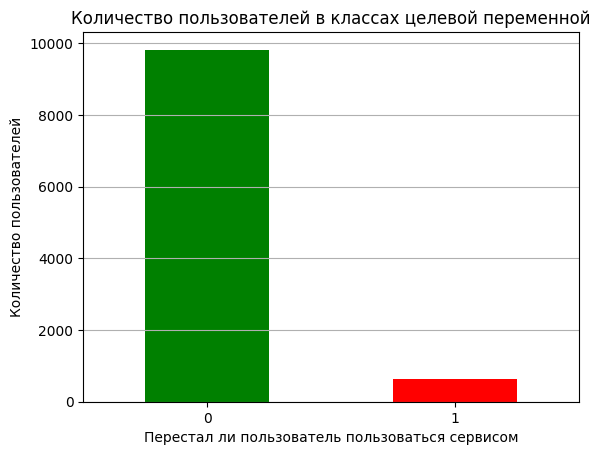

In [10]:
churn_val_count.plot(kind='bar', 
                                color=['green', 'red'], 
                                rot=0, 
                                xlabel='Перестал ли пользователь пользоваться сервисом',
                                ylabel='Количество пользователей',
                                title='Количество пользователей в классах целевой переменной'
                               ).grid(axis='y')

Как видно из анализа целевой переменной, в ней наблюдается сильный дисбаланс классов. Информации о людях, которые покидают сервис, почти в 15.5 раз меньше, чем информации о тех, кто продолжает пользоваться услугами сервиса. 

**Добавила анализ выбираемой метрики в зависимости от наличия дисбаланса:**

Если бы в проекте просили определить, какая доля клиентов из тех, что была выбрана моделью как "уходящие" действительно уйдет, то стоило бы выбрать метрику Precision. Если бы надо было определить, какую долю уходящих клиентов модель сможет обнаружить, то использовалась бы метрика Recall. Однако в проекте важны обе эти метрики. 

Можно было бы использовать, например, F1-меру, в этой метрике учитывается одинаковое влияние как Precision, так и Recall. Но данная метрика является зависимой от порога классификации, что может дать неполное представление о качестве модели.

Тогда подходящей метрикой для задачи проекта является метрика PR-AUC. Она фокусируется на редком положительном классе, не зависит от порога классификации, учитывает метрики Precision и Recall.

**Краткий вывод по заданию 2.2:** В целевой переменной наблюдается сильный дисбаланс классов - при условии, что надо спрогнозировать отток клиентов для сервиса, информации о пользователях, прекративших пользоваться услугами сервиса, намного меньше (в 15.5 раз), чем о тех, кто продолжает пользоваться услугами.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

<a class="anchor" id="2.3-bullet"></a>
#### Задание 2.3

Опишем признаки. Определим, все ли из них важны. Объясним, какие из них можно удалить и аргументируем решение.

In [11]:
print(f'Количество признаков: {len(df.columns) - 1}')

Количество признаков: 26


В датасете 26 признаков, многие из которых содержательные и, вероятнее всего, окажут влияние на предсказания. 

Как и было уточнено в пункте 2.1, признаки содержат общую статистическую информацию, которая может повлиять на решение пользователя уйти ему или остаться:
- суммы заказов;
- как часто совершаются заказы;
- вкусовые предпочтения;
- размеры заказов;
- опыт пользования приложением доставки;
- оценки заказов.

Без анализа можно уверенно удалить только столбец `user_id`, являющийсяя идентификационным. 

In [12]:
df = df.drop('user_id', axis=1)

**Краткий вывод по заданию 2.3:** На первый взгляд, многие признаки могут оказаться полезными для модели. В связи с этим был удален только идентификационный столбец `user_id`.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

<a class="anchor" id="2.4-bullet"></a>
#### Задание 2.4

Определим стратегию обработки пропущенных значений. Объясним, как они влияют на данные. Выберим способ заполнения пропусков.

Для начала вновь посмотрим на количество пропущенных значений.

In [13]:
pd.DataFrame({'Кол-во пропусков': df.iloc[:, :-1].isna().sum(), 
              'Доля пропусков': round(df.iloc[:, :-1].isna().sum() / df.shape[0], 2),
              'Процент пропусков': round(df.iloc[:, :-1].isna().sum() / df.shape[0], 2) * 100})

,Кол-во пропусков,Доля пропусков,Процент пропусков
days_since_last_order,945,0.09,9.0
order_frequency_month,600,0.06,6.0
order_frequency_week,388,0.04,4.0
avg_order_value,583,0.06,6.0
median_order_value,831,0.08,8.0
total_spent_last_month,294,0.03,3.0
total_spent_last_week,944,0.09,9.0
discount_usage_rate,397,0.04,4.0
last_coffee_type,258,0.02,2.0
preferred_roast,116,0.01,1.0


Пропусков в данных достаточно много, они присутствуют во всех столбцах с признаками и составляют от 1 до 9 процентов. Пропуски являются критичными для логистической регрессии, так как при отсутствии значений методы оптимизации и модели не могут корректно посчитать значения.

Прежде чем выбрать стратегию работы с пропусками, определим их тип. В описании данных проекта сказано, что они были собраны из внутренних систем компании: транзакционной базы данных, логов мобильного приложения и результатов опросов. Учитывая это, предположим типы пропусков:
- вероятно, в данных нет пропусков типа MAR, которые можно было бы объяснить наблюдаемыми данными из датасета;
- признаки, имеющие пропуски типа MNAR, это: `preferred_roast`, `milk_preference`, `seasonal_menu_tried` (но этот признак может быть и MСAR, если он основывается на истории заказов, например, из БД, а не опросе пользователей), возможно `coffee_preference_change`, но он так же может быть и MCAR. Эти пропуски могут быть связаны с тем фактором, что пользователи сервиса не захотели указывать в опросе подобную информацию о себе;
- все остальные признаки имеют тип MCAR - они, вероятнее всего, связаны с техническими ошибками при загрузке/выгрузке данных.

##### Работа с пропусками типа MCAR

Сначала определим стратегию работы с пропусками типа MCAR. Эти пропуски составляют в общей сумме довольно большой процент от всех данных, поэтому будет некорректно просто удалить их. Тогда заполним эти пропусками вычисленными медианными или средними значениями. Чтобы выбрать вид заполнения, посмотреть статистические данные об этих признаках.

In [14]:
# подготовим названия столбцов с пропусками типа MCAR/MNAR 
mcar_data = list(df.columns)
mnar_data = ['preferred_roast', 'milk_preference', 'seasonal_menu_tried', 'coffee_preference_change']
for el in mnar_data:
    mcar_data.remove(el)

mcar_data.remove('churn')

In [15]:
# проведем анализ числовых признаков с пропусками типа MCAR
mcar_num_data = df[mcar_data].describe().T[['mean', 'min', '50%', 'max']]
mcar_num_data['mean - median'] = mcar_num_data['mean'] - mcar_num_data['50%']
mcar_num_data = mcar_num_data.rename(columns={'50%': 'median'})
mcar_num_data

,mean,min,median,max,mean - median
days_since_last_order,4.394214,0.000000,3.000000,40.000000,1.394214
order_frequency_month,4.025666,0.011046,3.381094,27.389318,0.644572
order_frequency_week,0.930686,-0.169131,0.784839,6.302624,0.145848
avg_order_value,1063.741207,-32.075932,898.643524,5901.965278,165.097682
median_order_value,452.651500,-10.353340,406.456818,2189.101644,46.194682
total_spent_last_month,1946.132979,-43.716463,1300.409757,79298.849570,645.723222
total_spent_last_week,413.004760,-2290.559468,288.277327,8615.988952,124.727433
discount_usage_rate,0.284446,0.002162,0.264583,0.887301,0.019863
app_opens_per_week,11.330895,0.000000,9.228383,224.587876,2.102513
notifications_enabled,0.753052,0.000000,1.000000,1.000000,-0.246948


Определим, чем корректнее будет заполнять пропуски. Среднее арифметическое является чувствительным к выбросам. Уже на данном этапе заметны выбросы - отрицательные значения в столбцах, где их быть не должно, из-за чего среднее могло исказиться. В целом медиана и среднее почти для всех признаков отличаются не так сильно, кроме `avg_order_value`, `total_spent_last_month`, `total_spent_last_week`. В связи с этим, примем решение заполнить пропуски медианой, так как она более стабильна и является значением, разделяющим данные пополам.

In [16]:
# раздели признаки с пропусками типа MCAR на числовые и категориальные
mcar_num_columns = mcar_num_data.reset_index()['index']
mcar_cat_columns = mcar_data

for el in mcar_num_columns:
    mcar_cat_columns.remove(el)

In [17]:
# проведем анализ категориальных признаков с пропусками типа MCAR
mcar_cat_data = df[mcar_cat_columns].describe().T
# добавим информацию о проценте пропусков
mcar_cat_data['isna'] = round(df[mcar_cat_columns].isna().sum(), 2)
mcar_cat_data

,count,unique,top,freq,isna
last_coffee_type,10192,3,arabica,6134,258
coffee_bean_origin,9768,6,ethiopia,1690,682
last_drink_size,9946,3,medium,4925,504
subscription_status,9512,4,none,3803,938
seasons,9771,4,spring,2507,679
phone_type,10114,3,android,4611,336
geo_location,10340,100,geo_2,1629,110


Судя по данным, если мы заменим пропуски самым частым значением, то сильно завысим количество встреч одной из категорий (как раз частого значения). Вероятнее всего, для многих пользователей в таком случае получатся неверные категории, которые могут запутать модель. Потому что, например, для признака `coffee_bean_origin` количество пропущенных значений составляет 682, что меньше трети от частоты встреч самого частого значения "ethiopia" того же столбца (1690 раз). Тогда лучше заменить пропуски новой категорией "неизвестно".

##### Работа с пропусками типа MNAR

In [18]:
df[mnar_data].describe(include='all')

,preferred_roast,milk_preference,seasonal_menu_tried,coffee_preference_change
count,10334,9782,9461.000000,9840.000000
unique,3,6,NaN,NaN
top,medium,whole,NaN,NaN
freq,3458,2876,NaN,NaN
mean,NaN,NaN,0.701194,0.192480
std,NaN,NaN,0.457759,0.394268
min,NaN,NaN,0.000000,0.000000
25%,NaN,NaN,0.000000,0.000000
50%,NaN,NaN,1.000000,0.000000
75%,NaN,NaN,1.000000,0.000000


Как видно из статистических данных - признаки `seasonal_menu_tried`, `coffee_preference_change` являются бинарными, средние и медианные значения у них равны примерно 1 и 0 соответственно. Применим к ним ту же стратегию, что и с числовыми столбцами типа MCAR.

По той же причине, что и у категориальных признаков с пропусками типа MCAR, заменим у столбцов `preferred_roast`, `milk_preference` пропуски категорией "неизвестно".

По сути, если мы объединим числовые столбцы типа MCAR и MNAR, то просто получим список числовых столбцов. То же самое и с категориальными данными. Сделаем это для дальнейшей работы.

In [19]:
num_columns = list(mcar_num_columns)
num_columns.extend(['seasonal_menu_tried', 'coffee_preference_change'])
cat_columns = list(mcar_cat_columns)
cat_columns.extend(['preferred_roast', 'milk_preference'])
print(f'num_columns: {num_columns}\nlen: {len(num_columns)}\n\ncat_columns: {cat_columns}\nlen: {len(cat_columns)}')

num_columns: ['days_since_last_order', 'order_frequency_month', 'order_frequency_week', 'avg_order_value', 'median_order_value', 'total_spent_last_month', 'total_spent_last_week', 'discount_usage_rate', 'app_opens_per_week', 'notifications_enabled', 'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month', 'days_since_last_promo', 'seasonal_menu_tried', 'coffee_preference_change']
len: 16

cat_columns: ['last_coffee_type', 'coffee_bean_origin', 'last_drink_size', 'subscription_status', 'seasons', 'phone_type', 'geo_location', 'preferred_roast', 'milk_preference']
len: 9


**Краткий вывод по заданию 2.4:** Были исследованы пропуски в датасете. Каждый тип пропусков был исследован индивидуально, предположены причины их появления. Были определены дальнейшие стратегии работы с пропусками, сделаны заготовки списков с названиями колонок, которые будут использоваться в дальнейшем в пайплайне. 

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

<a class="anchor" id="2.5-bullet"></a>
#### Задание 2.5

Проанализируем категориальные признаки. Выясним, есть ли в данных признаки, которые можно кодировать. Объясним, почему именно их нужно кодировать. Проанализируем признаки на предмет того, можно ли использовать некоторые из них для генерации новых признаков. Укажем возможные стратегии. Определим, есть ли в данных признаки, которые можно удалить.

Рассмотрим категориальные признаки датасета.

Все категориальные признаки датасета, по сути, были сохранены в `cat_columns`. Воспользуемся этим списком названий для просмотра категориальных признаков.

In [20]:
df[cat_columns].head(3)

,last_coffee_type,coffee_bean_origin,last_drink_size,subscription_status,seasons,phone_type,geo_location,preferred_roast,milk_preference
0,blend,vietnam,large,pro,summer,android,geo_75,light,almond
1,arabica,guatemala,medium,none,autumn,ios,geo_95,light,whole
2,arabica,guatemala,small,premium,spring,web,geo_25,medium,oat


Посмотрим количество уникальных значений для каждого категориального признака.

In [21]:
df[cat_columns].nunique().sort_values()

last_coffee_type         3
last_drink_size          3
preferred_roast          3
phone_type               3
seasons                  4
subscription_status      4
coffee_bean_origin       6
milk_preference          6
geo_location           100
dtype: int64

Количество уникальных значений для каждого признака не такое большое, как у признака `geo_location`. Чтобы сделать вывод, можно ли удалять этот признак, посмотрим на вид его распределения. 

In [22]:
df['geo_location'].value_counts().sort_values(ascending=False)

geo_location
geo_2     1629
geo_3     1573
geo_1     1532
geo_99     117
geo_95     110
          ... 
geo_41      42
geo_45      41
geo_55      41
geo_60      40
geo_86      38
Name: count, Length: 100, dtype: int64

Судя по количеству пользователей в каждом регионе, люди распределены по ним крайне неравномерно - основная масса клиентов сосредоточилась в первых 3 районах (`geo_1`, `geo_2`, `geo_3` по 1532, 1629, 1573 человек соот-но), в то время как во всех оставшихся 97 регионах от 38 до 117 человек. Это может создать сложности для модели (статистически ненадежная основа для анализа). В регионах, где мало людей, модель будет остро реагировать на уход даже пары клиентов, может начать переобучаться, стараясь запомнить закономерности для "мелких" регионов. Кроме того, ценная информация географических паттернов может выражаться через другие, более подходящие для анализа и более значимые столбцы. Например, через столбец со средним чеком или средним числом заказов в неделю.  

Тогда, по описанным выше причинам, столбец `geo_location` может быть удален. 

Проанализируем, какие признаки по содержанию могут быть удалены:
- `last_coffee_type` - сорт кофе, купленный пользователем в последний раз на момент сбора данных. Вероятно, этот признак можно удалить, так как вряд ли именно содержание последнего заказа могло глобально повлиять на уход клиента;
- `last_drink_size` - такая же логика и для этого признака с размером последнего заказа;
- `phone_type` - тип устройства так же вряд ли мог повлиять на уход;
- `geo_location` - регион пользователя может быть удален по причинами, описанным выше.

Проанализируем, почему другие признаки стоит оставить:
- `preferred_roast` - предпочитаемый тип обжарки  мог повиять на уход клиента - например, если его любимый сорт кофе на данном сервисе не делают. То же самое можно сказать и о стране происхождения зерна `coffee_bean_origin`, предпочитаемом типе молока `milk_preference`;
-  `seasons` - сезон мог значительно повлиять на решение клиента - например, зимой возникает более острая необходимость в покупке кофе за счет низких температур на улице, в то время как летом наоборот - более актуальны холодные напитки;
- `subscription_status` - тип подписки так же мог повлиять. Вероятно, люди с подпиской уходят с сервиса реже, нежели люди без подписки.

In [23]:
for_remove = ['last_coffee_type', 'last_drink_size', 'phone_type', 'geo_location']
df = df.drop(for_remove, axis=1)
for el in for_remove:
    cat_columns.remove(el)

Посмотрим значения оставшихся категориальных данных.

In [24]:
df[cat_columns].nunique().sort_values()

preferred_roast        3
subscription_status    4
seasons                4
coffee_bean_origin     6
milk_preference        6
dtype: int64

Чтобы не потерять важную информацию из данных признаков, их стоит закодировать. В целом, у всех признаков уникальных категорий достаточно мало и их можно было бы закодировать с помощью One-Hot Encoding. Однако если мы закодируем признаки с помощью one-hot, то получим довольно много новых столбцов (3 + 4 + 4 + 6 + 6 = 23 новых столбца), поэтому лучше использовать Target Encoding.

*Добавление новых признаков*

В рамках работы с категориальными признаками, добавление новых признаков подразумевает под собой кодирование изначальных категориальных признаков.

Предположим в таком случае, какие новые признаки можно добавить, основываясь на числовых данных:
- признак, равный квадрату значений признака `app_crashes_last_month`. Пояснение: чем больше приложение зависает за месяц, тем меньше у пользователей желание совершать на этом сервисе покупки. При этом небольшие зависания не оказывают сильного влияния на пользователей. Поэтому увеличим влияние больших значений этого признака, возведя их в квадрат;
- признак, равный корню из `avg_order_value`. Пояснение: средний чек заказа не оказывает прямого влияния на уход человека. Нет гарантии, что пользователь, совершивший однажды заказ на большую сумму, вернется. Поэтому сгладим большие значения с помощью корня;
- признак, равный произведению признаков `order_frequency_month` и `avg_order_value`. Пояснение: отдельно, как было описано выше, признак `avg_order_value` стоило "сгладить". Однако в сочетании со средним числом заказов в месяц, их комбинация может дать большее влияние - чем чаще пользоватеь делает заказы и чем больше средний чек заказа (не обязательно, чтобы этот чек был очень высоким, будет лучше, если он будет средним, но количество заказов большое), тем вероятнее, что человек вернется за кофе. 

**Краткий вывод по заданию 2.5:** Были удалены категориальные столбцы `last_coffee_type`, `last_drink_size`, `phone_type`, так как они, вероятно, не окажут влияния на предсказания модели. Было принято решение кодировать оставшиеся категориальные признаки с помощью target encoding, чтобы не получить слишком большого количества новых столбцов и учесть связь категорий с целевой переменной. Были предложены варианты новых числовых признаков.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

<a class="anchor" id="2.6-bullet"></a>
#### Задание 2.6

Проанализируем выбросы. Определим, как они влияют на данные. Выберим способ, которым их можно обработать.

Обработаем выбросы в числовых столбцах. Но для начала, отдельно рассмотрим бинарные признаки. 

In [25]:
binary = ['seasonal_menu_tried', 'notifications_enabled', 'coffee_preference_change']
df[binary].describe()

,seasonal_menu_tried,notifications_enabled,coffee_preference_change
count,9461.000000,9913.000000,9840.000000
mean,0.701194,0.753052,0.192480
std,0.457759,0.431258,0.394268
min,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000
50%,1.000000,1.000000,0.000000
75%,1.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000


Явных выбросов (отрицательных значений, значений больше 1) нет. Проверим, встречаются ли в столбцах другие значения, помимо 0 и 1. 

In [26]:
for binar in binary:
    print(f'Признак: {binar}\n{df[(df[binar] != 0) & (df[binar] != 1) & (df[binar].notna())]}\n')

Признак: seasonal_menu_tried
Empty DataFrame
Columns: [days_since_last_order, order_frequency_month, order_frequency_week, avg_order_value, median_order_value, total_spent_last_month, total_spent_last_week, discount_usage_rate, preferred_roast, milk_preference, seasonal_menu_tried, coffee_bean_origin, subscription_status, app_opens_per_week, notifications_enabled, review_rating_last_10, review_rating_last_1, app_crashes_last_month, seasons, days_since_last_promo, coffee_preference_change, churn]
Index: []

[0 rows x 22 columns]

Признак: notifications_enabled
Empty DataFrame
Columns: [days_since_last_order, order_frequency_month, order_frequency_week, avg_order_value, median_order_value, total_spent_last_month, total_spent_last_week, discount_usage_rate, preferred_roast, milk_preference, seasonal_menu_tried, coffee_bean_origin, subscription_status, app_opens_per_week, notifications_enabled, review_rating_last_10, review_rating_last_1, app_crashes_last_month, seasons, days_since_last_pr

Таким образом, в данных столбцах выбросов нет. Перейдем к проверке признаков с непрерывными числовыми значениями.

In [27]:
# отделим числовые столбцы от бинарных
num = num_columns.copy()
for el in binary:
    num.remove(el)
len(num)

13

Сначала посмотрим на статистические данные.

In [28]:
df[num].describe()

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,app_opens_per_week,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo
count,9505.000000,9850.000000,10062.000000,9867.000000,9619.000000,10156.000000,9506.000000,10053.000000,9554.000000,9757.000000,9593.000000,9729.000000,9719.000000
mean,4.394214,4.025666,0.930686,1063.741207,452.651500,1946.132979,413.004760,0.284446,11.330895,4.206709,4.022460,1.013362,14.554584
std,4.858757,2.826144,0.657261,707.713396,258.657571,2370.619590,445.634902,0.158735,14.528887,0.782212,1.207883,1.010342,15.308869
min,0.000000,0.011046,-0.169131,-32.075932,-10.353340,-43.716463,-2290.559468,0.002162,0.000000,1.415526,-0.897000,0.000000,0.000000
25%,1.000000,1.937767,0.445185,552.898663,262.908598,629.680382,136.565833,0.159884,6.313628,3.675543,3.214157,0.000000,4.000000
50%,3.000000,3.381094,0.784839,898.643524,406.456818,1300.409757,288.277327,0.264583,9.228383,4.203555,3.990032,1.000000,10.000000
75%,6.000000,5.439363,1.262350,1406.332153,590.418070,2481.650495,549.699420,0.387056,12.726649,4.717292,4.845225,2.000000,20.000000
max,40.000000,27.389318,6.302624,5901.965278,2189.101644,79298.849570,8615.988952,0.887301,224.587876,7.384425,8.558443,7.000000,140.000000


В столбцах `order_frequency_week`, `avg_order_value`, `median_order_value`, `total_spent_last_month`, `total_spent_last_week`, `review_rating_last_1` содержатся очевидные отрицательные выбросы - данные столбцы не могут иметь отрицательные значения.

In [29]:
# оставим список-заготовку для следующих этапов работы. 
# Нужные нам столбцы - единственные столбцы с отриц. значениями. 
# Зная это, добавим названия нужных колонок в список не вручную
columns_negative = []

for el in df.columns:
    if df[el].dtype != 'str' and df[el].min() < 0:
        columns_negative.append(el)
        
columns_negative

['order_frequency_week',
 'avg_order_value',
 'median_order_value',
 'total_spent_last_month',
 'total_spent_last_week',
 'review_rating_last_1']

Данные выбросы повлияли бы некорректно на работу модели - отрицательные значения искажают картину, в то время когда столбцы физически не могут содержать отрицательных значений.

Построим гистограммы для непрерывных числовых признаков. Перед этим удалим из списка признаков еще один дискретный признак (`app_crashes_last_month`) и добавим его в список к бинарным признакам.

In [30]:
binary.append('app_crashes_last_month')
num.remove('app_crashes_last_month')
discrete_features = binary.copy()

Построение гистограмм для непрерывных числовых признаков.

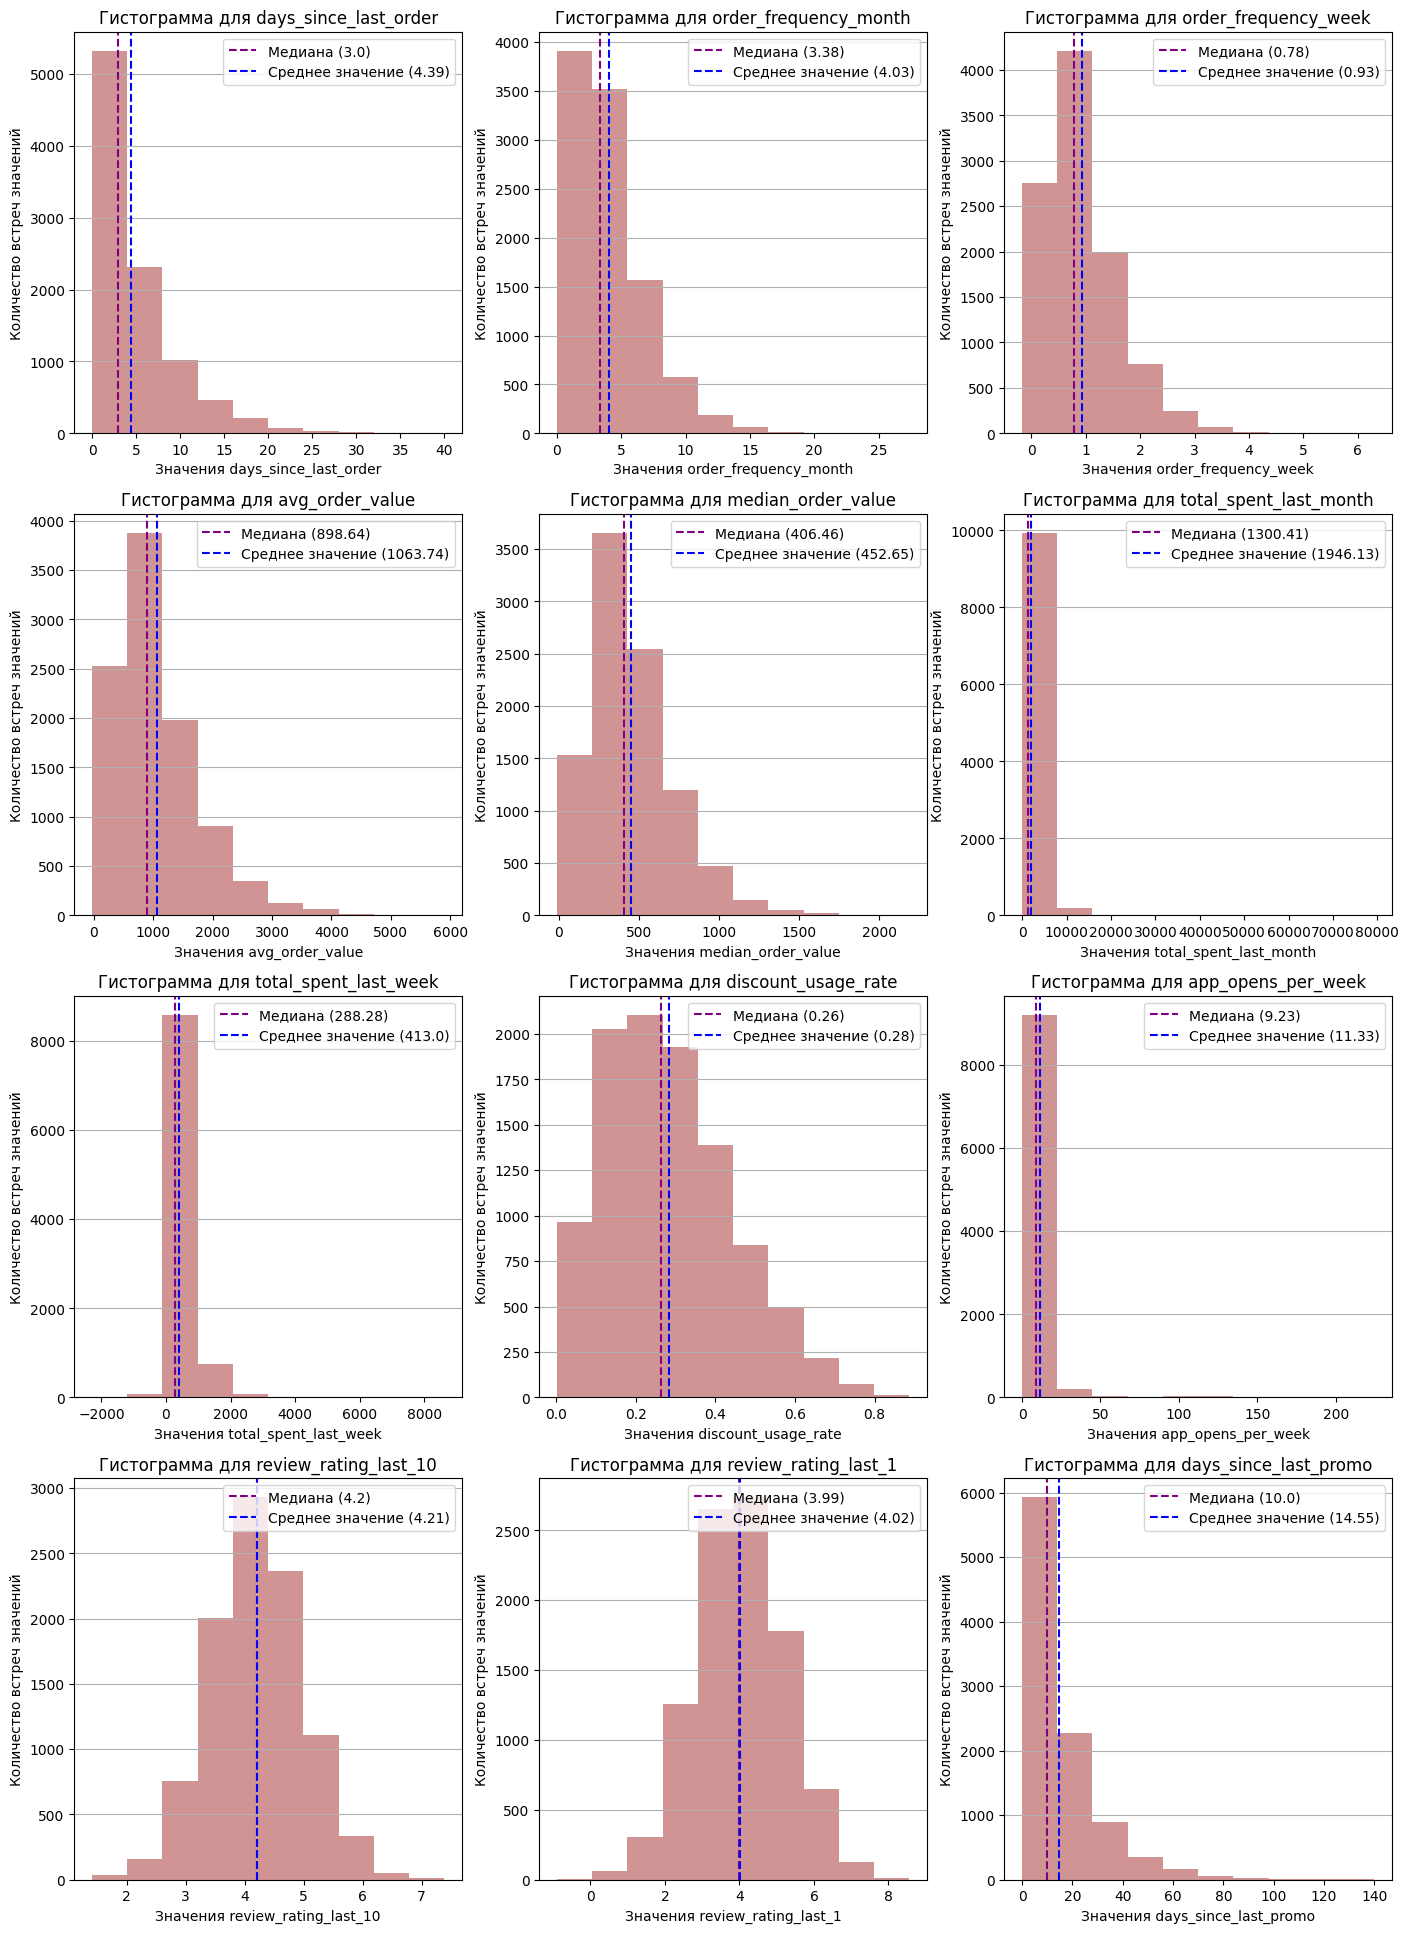

In [31]:
fig, axs = plt.subplots(4, 3, figsize=(17, 24))
for sign in range(len(num)):
    values = df[num[sign]][df[num[sign]].notna()]
    
    median_value = values.median()
    mean_value = values.mean()

    axs[sign // 3, sign % 3].hist(values, color='brown', alpha=0.5)
    axs[sign // 3, sign % 3].set_title(f'Гистограмма для {num[sign]}')
    axs[sign // 3, sign % 3].grid(axis='y')
    axs[sign // 3, sign % 3].set_xlabel(f'Значения {num[sign]}')
    axs[sign // 3, sign % 3].set_ylabel(f'Количество встреч значений')
    axs[sign // 3, sign % 3].axvline(median_value, label=f'Медиана ({round(median_value, 2)})', linewidth=1.5, linestyle='--', color='purple')
    axs[sign // 3, sign % 3].axvline(mean_value, label=f'Среднее значение ({round(mean_value, 2)})', linewidth=1.5, linestyle='--', color='blue')
    axs[sign // 3, sign % 3].legend()

Построим столбчатые диаграммы для графического анализа дискретных признаков.

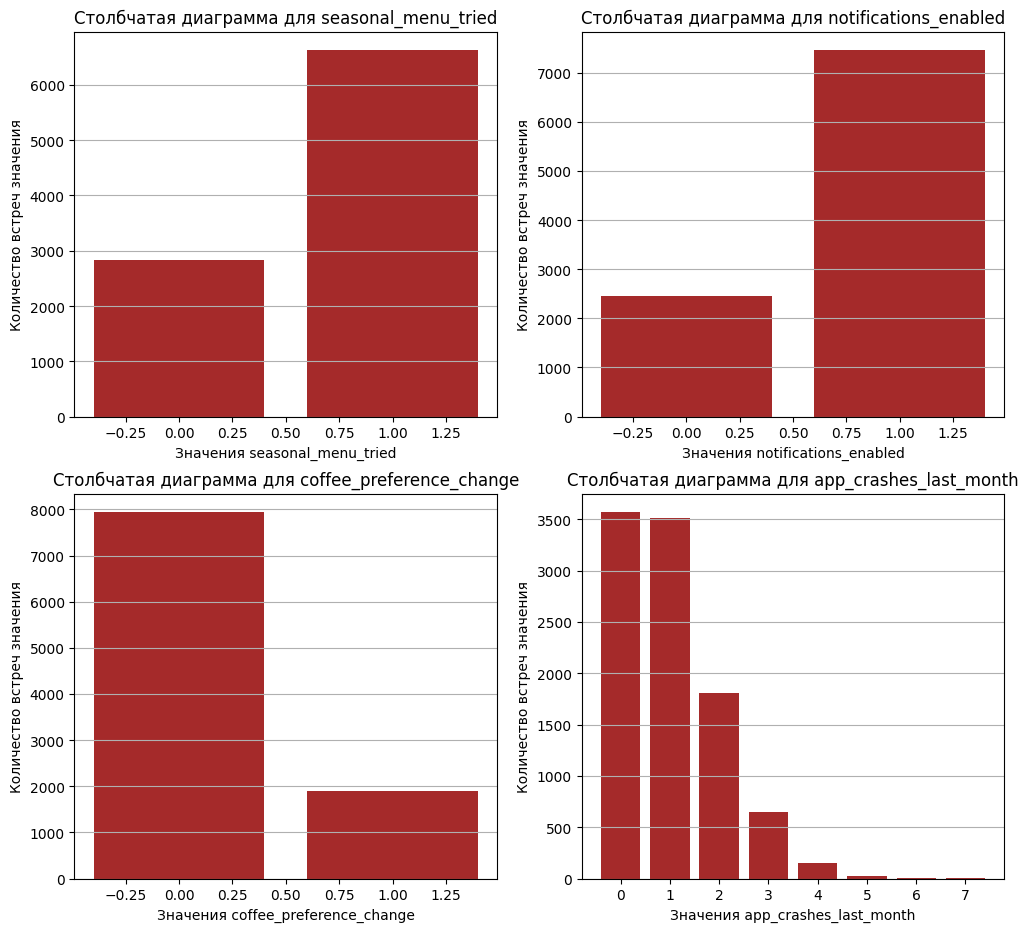

In [32]:
fig, axs = plt.subplots(2, 2, figsize=(12, 11))
for sign in range(len(discrete_features)):
    values = df[discrete_features[sign]][df[discrete_features[sign]].notna()].value_counts().reset_index()

    axs[sign // 2, sign % 2].bar(values.iloc[:, 0], values.iloc[:, 1], color='brown')
    axs[sign // 2, sign % 2].set_title(f'Столбчатая диаграмма для {discrete_features[sign]}')
    axs[sign // 2, sign % 2].grid(axis='y')
    axs[sign // 2, sign % 2].set_xlabel(f'Значения {discrete_features[sign]}')
    axs[sign // 2, sign % 2].set_ylabel(f'Количество встреч значения')

Для получения полной картины так же построим диаграммы размаха для непрерывных числовых признаков.

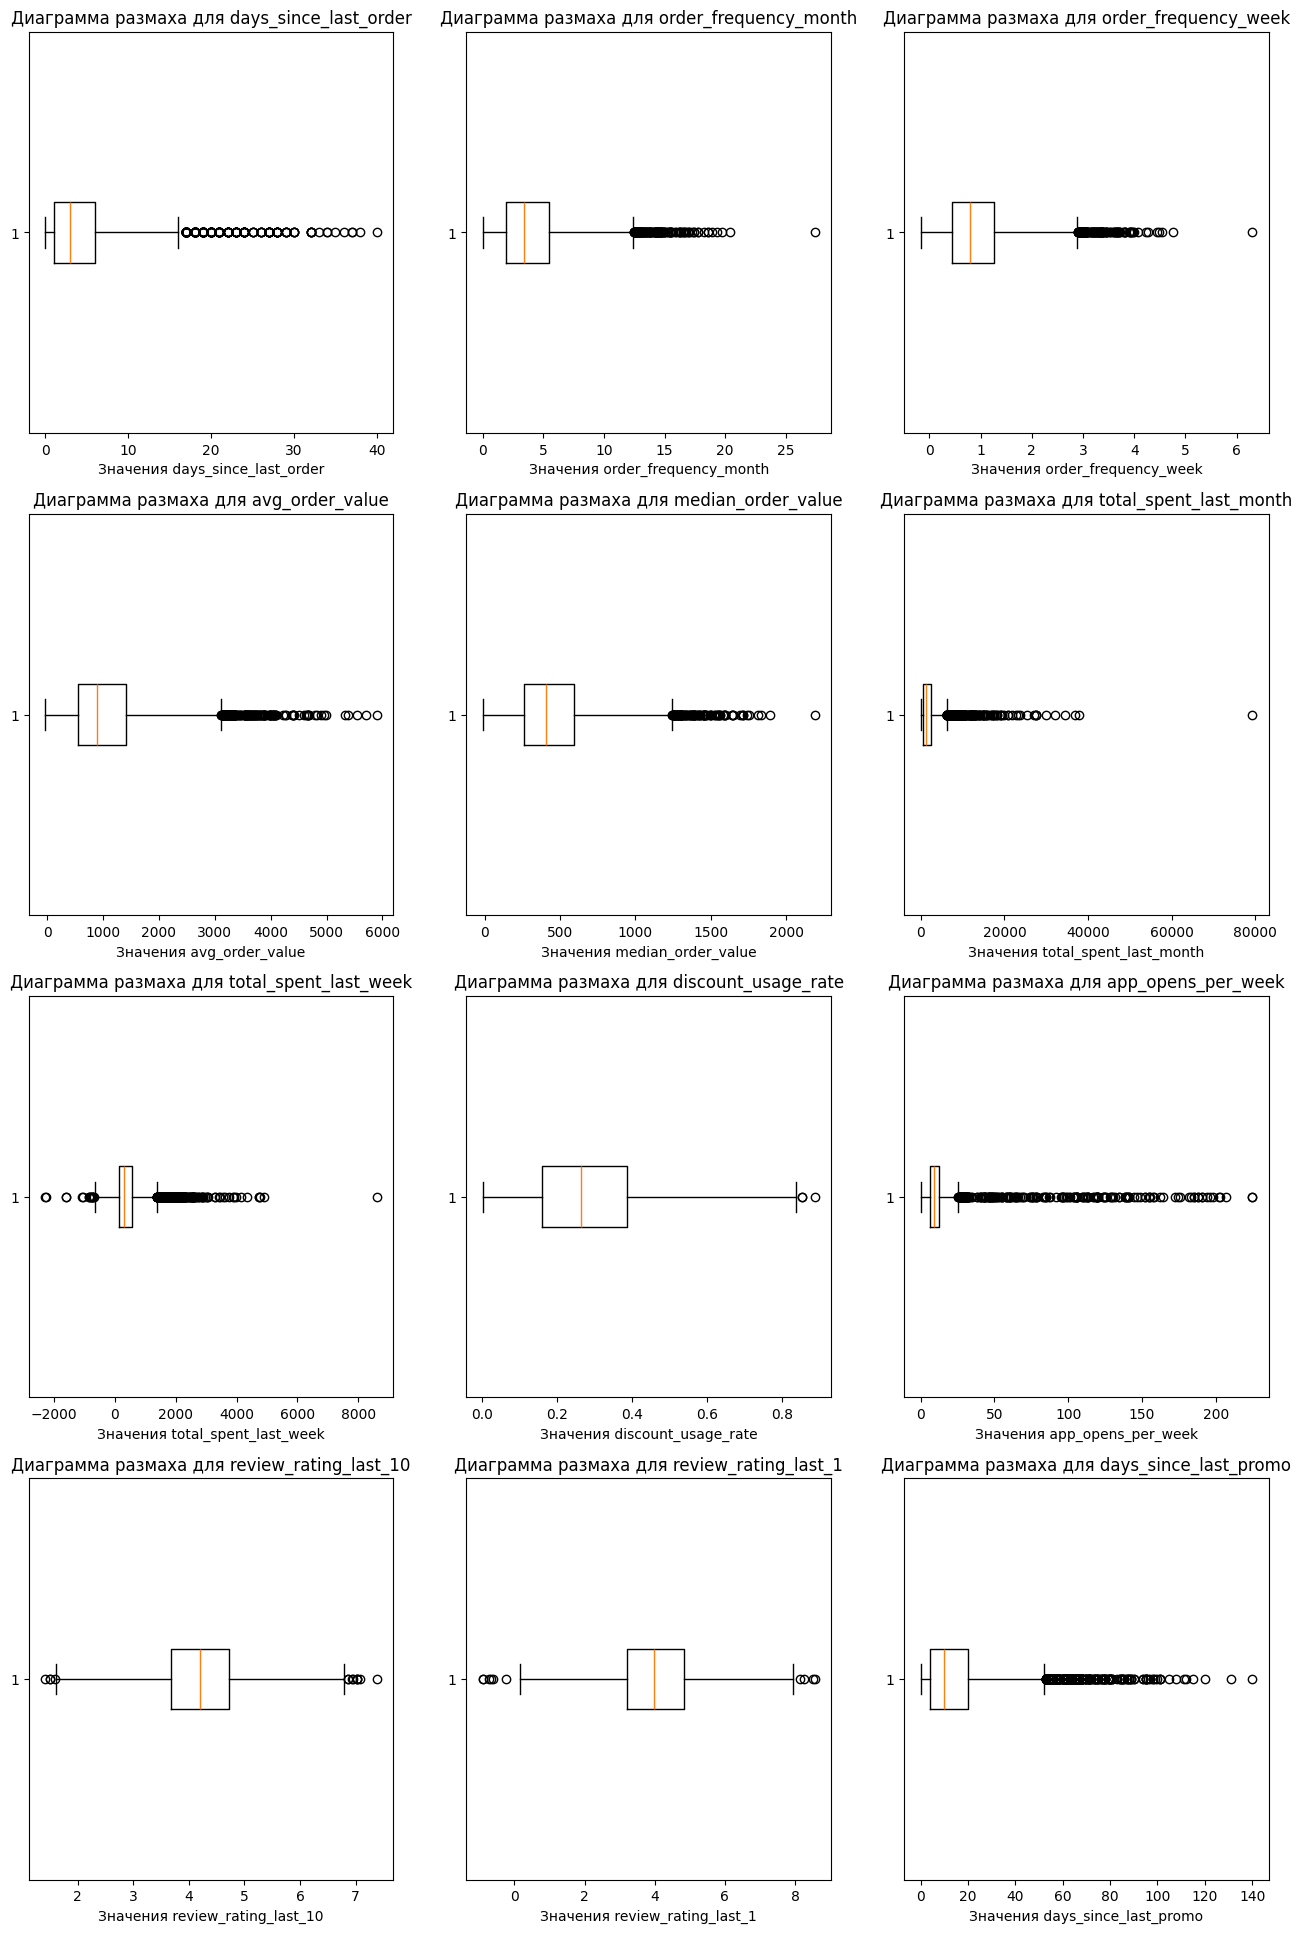

In [33]:
fig, axs = plt.subplots(4, 3, figsize=(16, 24))
for sign in range(len(num)):
    values = df[num[sign]][df[num[sign]].notna()]

    axs[sign // 3, sign % 3].boxplot(values, vert=False, whis=2)
    axs[sign // 3, sign % 3].set_title(f'Диаграмма размаха для {num[sign]}')
    axs[sign // 3, sign % 3].set_xlabel(f'Значения {num[sign]}')

Судя по гистограммам, почти нормальное распределение имеют признаки `review_rating_last_10`, `discount_usage_rate` и `review_rating_last_1` - пик достигается посередине графика, левый и правый хвост примерно похожи, медиана пости совпадает со средним значением.

Немного правоассиметичное распределение по гистограмме видно на столбцах `days_since_last_order`, `order_frequency_month`, `order_frequency_week`, `avg_order_value`, `median_order_value`. Если смотреть по диаграммам размаха, то у `order_frequency_month`, `order_frequency_week`, `median_order_value` есть одиночные аномальные значения в зоне больших значений. Вероятно, это выбросы, которые стоит убрать.

Столбцы `total_spent_last_month`, `total_spent_last_week`, `app_opens_per_week`, `days_since_last_promo` имеют довольно сильно правоассиметричное распределение. Причиной такого распределения, как показывают диаграммы размаха, являются так же единичные выбросы в зоне больших значений.

Вероятно, эти единичные выбросы являются воссозданными искусственно. Чтобы избавиться от них, напишем свою функцию, которая оставит только те значения, которые меньше максимального. Применим это для столбцов `order_frequency_month`, `order_frequency_week`, `median_order_value`, `total_spent_last_month`, `total_spent_last_week`, `app_opens_per_week`. Остальные значения оставим как есть.

Данные выбросы могут запутать модель - в то время, как значения являются невозможными, модель будет стараться провести линию между классами, беря эти значения во внимание. Поэтому для получения корректной работы модели с выбросами нужно провести работу. 

Если рассматривать столбчатые диаграммы для дискретных признаков, то можно увидеть, что значения признаков `seasonal_menu_tried`, `notifications_enabled`, `coffee_preference_change` выглядят допустимыми: для некоторых признаков возобладает количество единиц над нулями, для других - наоборот. Нет экстремально низкого или большого количества представителей обоих классов. В то время как у признака `app_crashes_last_month` видно достаточно низкое количество значений в районе 5-7 зависаний приложения в месяц. Хотя эти значения встречаются очень редко, они не выглядят аномальными - количество зависаний планомерно идет от 0 до 7, с увеличением количества зависаний, уменьшается количество людей, которые с ними встретились. Значит этот признак, вероятнее всего, не содержит выбросов.

In [34]:
# составим список - заготовку на будущие этапы работы 
columns_emissions = ['order_frequency_month', 'order_frequency_week', 'median_order_value', 'total_spent_last_month', 'total_spent_last_week', 'app_opens_per_week']

**Краткий вывод по заданию 2.6:** были рассмотрены бинарные данные, выбросов в них не нашлось, а также числовые признаки - было принято решение удалить строки с отрицательными значениями в столбцах `order_frequency_week`, `avg_order_value`, `median_order_value`, `total_spent_last_month`, `total_spent_last_week`, `review_rating_last_1`, так как отрицательными они быть не могут, а также для столбцов `order_frequency_month`, `order_frequency_week`, `median_order_value`, `total_spent_last_month`, `total_spent_last_week`, `app_opens_per_week` написать функцию, которая оставит значения, которые меньше максимального.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

<a class="anchor" id="2.7-bullet"></a>
#### Задание 2.7

Посчитаем корреляции между признаками. Построим необходимые визуализации. Определим, есть ли признаки, которые можно убрать, на основании их корреляции с другими.

In [35]:
# все непрерывные числовые признаки ранее были сохранены в num
correlation = df.iloc[:, :-1].phik_matrix(interval_cols=num)
correlation

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,preferred_roast,milk_preference,...,coffee_bean_origin,subscription_status,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,coffee_preference_change
days_since_last_order,1.000000,0.000000,0.000000,0.000000,0.012729,0.000000,0.000000,0.000000,0.034494,0.023271,...,0.000000,0.000000,0.000000,0.026565,0.027785,0.066396,0.000000,0.000000,0.000000,0.022482
order_frequency_month,0.000000,1.000000,0.990083,0.000000,0.099037,0.414983,0.472064,0.000000,0.000000,0.009407,...,0.016783,0.000000,0.199785,0.000000,0.017989,0.000000,0.025061,0.009243,0.000000,0.000000
order_frequency_week,0.000000,0.990083,1.000000,0.000000,0.096402,0.382369,0.473355,0.016060,0.000000,0.000000,...,0.017263,0.000000,0.179130,0.002027,0.000000,0.000000,0.000000,0.011682,0.000000,0.008724
avg_order_value,0.000000,0.000000,0.000000,1.000000,0.890398,0.166837,0.285857,0.023184,0.000000,0.000000,...,0.013409,0.000000,0.000000,0.000000,0.038050,0.000000,0.034559,0.000000,0.063572,0.000000
median_order_value,0.012729,0.099037,0.096402,0.890398,1.000000,0.446017,0.695032,0.032947,0.000000,0.018388,...,0.000000,0.038636,0.012567,0.028692,0.000000,0.000000,0.000000,0.019665,0.000000,0.026813
total_spent_last_month,0.000000,0.414983,0.382369,0.166837,0.446017,1.000000,0.609608,0.027281,0.000000,0.000000,...,0.000000,0.019712,0.459848,0.000000,0.000000,0.000000,0.000000,0.026626,0.000000,0.025709
total_spent_last_week,0.000000,0.472064,0.473355,0.285857,0.695032,0.609608,1.000000,0.002044,0.000000,0.000000,...,0.029290,0.026496,0.094457,0.005031,0.000000,0.000000,0.000000,0.026038,0.000000,0.000000
discount_usage_rate,0.000000,0.000000,0.016060,0.023184,0.032947,0.027281,0.002044,1.000000,0.000000,0.038955,...,0.000000,0.025947,0.000000,0.011988,0.008239,0.000000,0.000000,0.026710,0.000000,0.036829
preferred_roast,0.034494,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.021292,0.000000,0.031336,0.009243,0.041330,0.004573,0.012704,0.000000,0.000000,0.000000
milk_preference,0.023271,0.009407,0.000000,0.000000,0.018388,0.000000,0.000000,0.038955,0.000000,1.000000,...,0.000000,0.000000,0.025031,0.020933,0.043956,0.009094,0.029884,0.032692,0.032792,0.000000


Text(0.5, 1.0, 'Матрица корреляций для всех признаков')

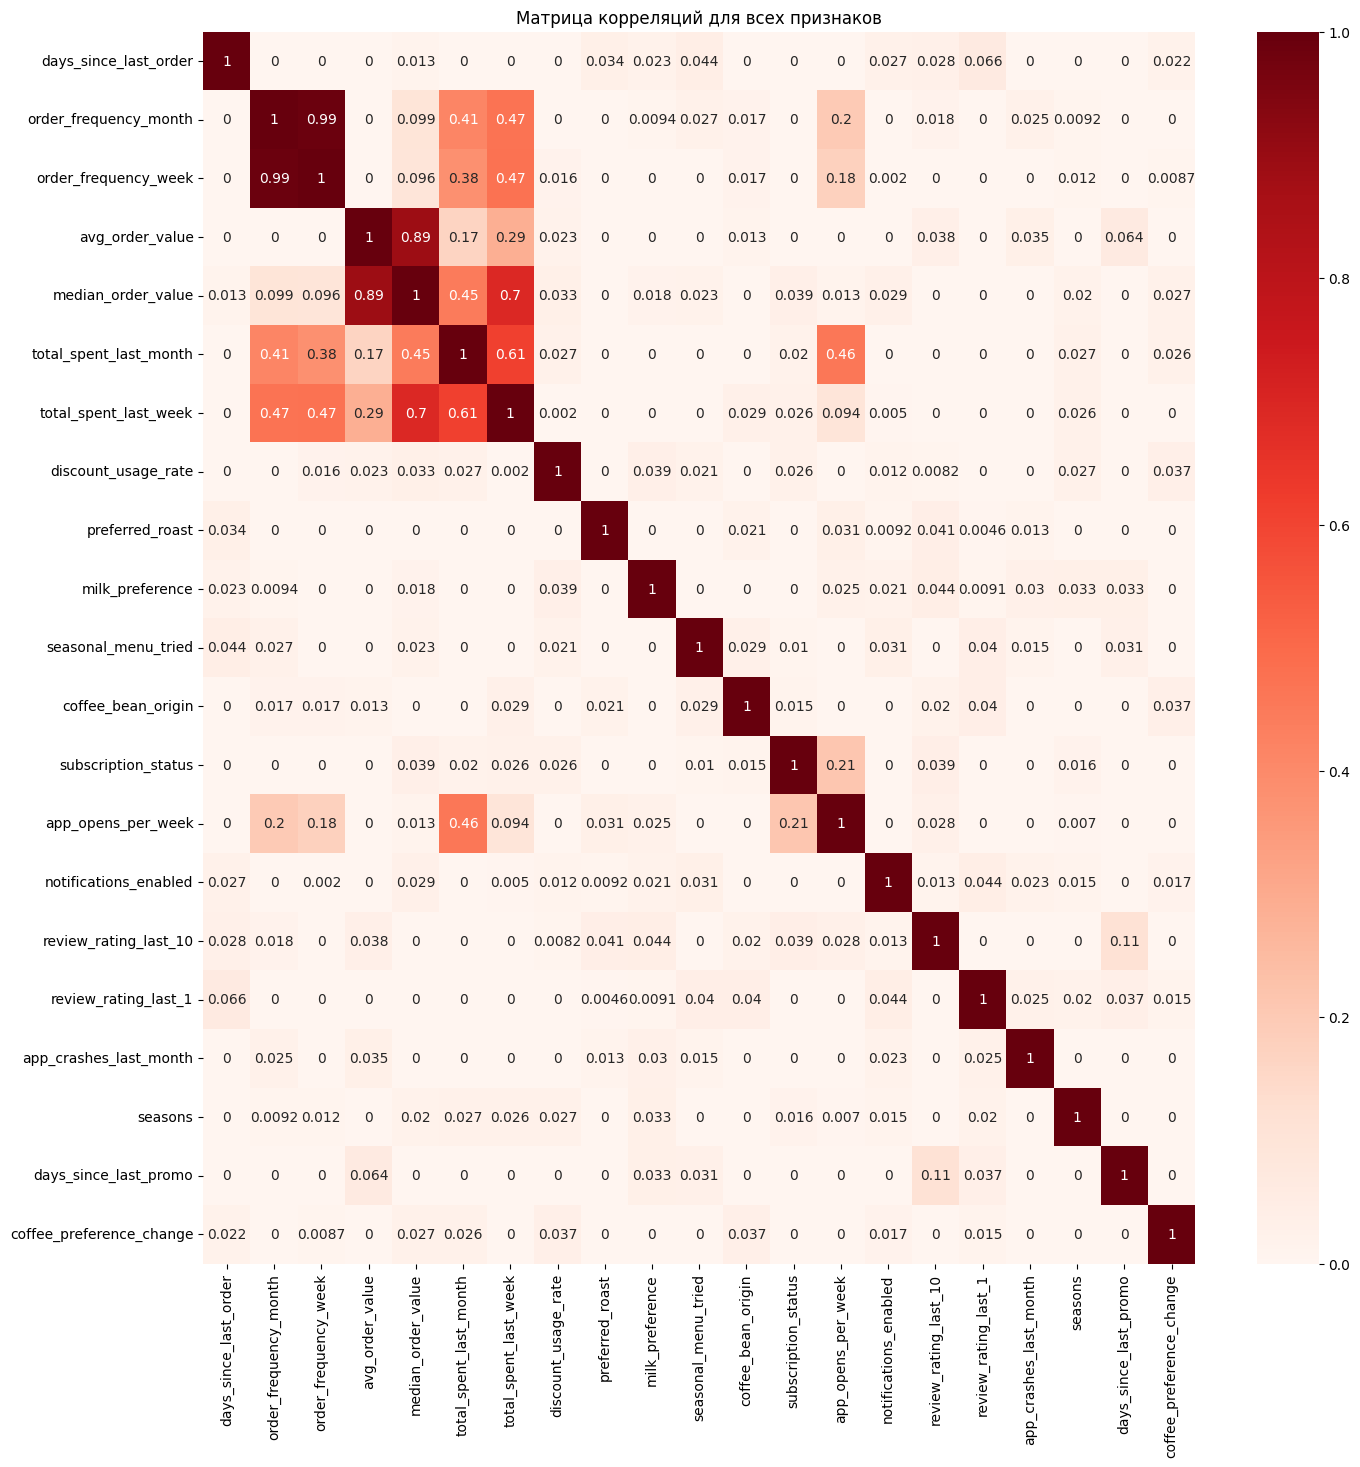

In [36]:
plt.figure(figsize=(16, 16))
sns.heatmap(correlation, cmap='Reds', annot=True)
plt.title('Матрица корреляций для всех признаков')

Матрица корреляции позволяет акцентировать внимание на сильной корреляции признаков `order_frequency_week` и `order_frequency_month` - корреляция равна 0.99, а также признаков `median_order_value` и `avg_order_value` и равна 0.89.

Вероятно, связь между `order_frequency_week` и `order_frequency_month` обусловлена тем, что среднее число заказов в месяц и в неделю действительно зависят друг от друга - чем больше заказов в неделю, тем больше и в месяц. Тогда на основе корреляции лучше удалить признак `order_frequency_week`, так как `order_frequency_month` и так будет нести в себе достаточно информации о среднем числе заказов.

Связь между `median_order_value` и `avg_order_value` обусловлена тем, что средний и медианный чеки совпадают, что вероятно при нормальном распределении. В таком случае оставим только один признак - `avg_order_value`, отвечающий за средний чек.

Удалим данные признаки из датасета и "заготовок" для следующих этапов.

In [37]:
for_drop = ['order_frequency_week', 'median_order_value']
df = df.drop(['order_frequency_week', 'median_order_value'], axis=1)

In [38]:
for el in for_drop:
    num_columns.remove(el)
    columns_emissions.remove(el)
    columns_negative.remove(el)

**Краткий вывод по заданию 2.7:** На основе сильной корреляции между признаками `order_frequency_week` и `order_frequency_month` было принято решение удалить столбец `order_frequency_week`, а также на основе зависимости `median_order_value` и `avg_order_value` - столбец `median_order_value`.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

<a class="anchor" id="2.8-bullet"></a>
#### Задание 2.8

В результате исследовательского анализа были сделаны следующие вещи:
- выяснилось, что в целевой переменной наблюдается сильный дисбаланс классов - при условии, что надо спрогнозировать отток клиентов для сервиса, информации о пользователях, прекративших пользоваться услугами сервиса, намного меньше (в 15.5 раз), чем о тех, кто продолжает пользоваться услугами;
- был удален только идентификационный столбец `user_id`;
- были исследованы пропуски в датасете. Каждый тип пропусков был исследован индивидуально, предположены причины их появления. Были определены дальнейшие стратегии работы с пропусками, сделаны заготовки списков с названиями колонок, которые будут использоваться в дальнейшем в пайплайне;
- были удалены категориальные столбцы `last_coffee_type`, `last_drink_size`, `phone_type. Было принято решение кодировать оставшиеся категориальные признаки с помощью target encoding, чтобы не получить слишком большого количества новых столбцов и учесть связь категорий с целевой переменной. Были предложены варианты новых числовых признаков;
- были рассмотрены бинарные данные, выбросов в них не нашлось, а также числовые признаки - было принято решение удалить строки с отрицательными значениями в столбцах `order_frequency_week`, `avg_order_value`, `median_order_value`, `total_spent_last_month`, `total_spent_last_week`, `review_rating_last_1`, так как отрицательными они быть не могут, а также для столбцов `order_frequency_month`, `order_frequency_week`, `median_order_value`, `total_spent_last_month`, `total_spent_last_week`, `app_opens_per_week`, `app_crashes_last_month` написать функцию, которая оставит значения, которые меньше максимального;
- на основе сильной корреляции между признаками order_frequency_week и order_frequency_month было принято решение удалить столбец order_frequency_week, а также на основе зависимости median_order_value и avg_order_value - столбец median_order_value.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

<a class="anchor" id="3-bullet"></a>
## Этап 3. Предобработка данных

Обработаем выбросы в данных в соответствии со стратегиями, выбранными ранее:
- уберем из столбцов, содержащихся в `columns_negative`, отрицательные значения;
- так как, вероятно, выбросы в столбцах `columns_emissions` были синтетическими, поступим не стандартным способом, а просто отфильтруем по наибольшему значению.

In [39]:
# обработаем отрицательные значения 
for el in columns_negative:
    df = df[df[el] > 0]

# обработаем выбросы
for el in columns_emissions:
    df = df[df[el] < max(df[el]) - 1]

Разделим данные в пропорции 80 к 20, оставив 20% на тест.

In [40]:
X, y = df.drop('churn', axis=1), df['churn']
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size = 0.2, shuffle=True, stratify=y, random_state=42)

In [41]:
print(f'''Размеры выборок:
X_train_val: {X_train_val.shape}
y_train_val: {y_train_val.shape}
X_test: {X_test.shape}
y_test: {y_test.shape}''')

Размеры выборок:
X_train_val: (5410, 19)
y_train_val: (5410,)
X_test: (1353, 19)
y_test: (1353,)


Размер выборки для тренировку и валидации составил 5410 строк и 19 столбцов, для теста - 1353 строки и, соответственно, столько же признаков.

Создадим пайплайны:
- `num_processing` для работы с числовыми значениями - заполнения пропусков и стандартизации;
- `cat_processing` для работы с категориальными данными - заполнения пропусков и целевого кодирования.

В качестве масштабирования числовых признаков была выбрана стандартизация, так как большинство признаков распределено неравномерно. Из-за этого, если бы был выбран мин-макс, большинство значений могли бы оказаться в очень плотной области, в то время как в другой чатси области встречались бы редкие значения из хвоста. 

In [42]:
num_processing = Pipeline(steps=
                         [
                             ('imputer_num', SimpleImputer(strategy='median')),
                             ('scaler', StandardScaler())
                         ])
cat_processing = Pipeline(steps=
                        [
                            ('imputer_cat', SimpleImputer(strategy='constant', fill_value='Неизвестно')),
                            ('target_enc', TargetEncoder())
                        ])

Создадим трансформер для объединения пайплайнов.

In [43]:
preprocessor = ColumnTransformer(transformers=[
    ('num_processing', num_processing, num_columns),
    ('cat_processing', cat_processing, cat_columns)
])

**Краткий вывод по этапу 3:** Данные были разделены: часть на тест, часть для обучения и кросс-валидации. Были созданы пайплайны для обработки числовых и категориальных признаков, трансформер, объединивший пайплайны.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

<a class="anchor" id="4-bullet"></a>
## Этап 4. Обучение модели

Создадим модели для получения предсказаний. Будем использовать автоматическую кросс-валидацию, которая позволит каждому объекту побывать как в роли обучающего, так и в роли валидационного объекта.

Для моделей в качестве метрик будем использовать `log loss` и `pr auc`:
- Метрика `log loss` является стандартной для задач бинарной классификации и показывает, насколько уверенно модель дает свои предсказания, и в целом соответствуют ли эти предсказания истинным меткам;
- Метрика `pr auc` укажет на то, способна ли модель находить объекты истинного класса при условии дисбаланса классов, где количество меток истинного класса достаточно мало.

In [45]:
scoring = ['neg_log_loss', 'average_precision']

Для начала, создадим простейшую Dummy-модель, которая будет предсказывать наиболее часто встречающееся значение. С ней будет происходить сравнение других моделей.

#### Dummy-модель

Создадим объект класса KFold для кросс-валидации.

In [46]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

Создадим пайплайн для Dummy-модели, запустим автоматическую кросс-валидацию.

In [47]:
pipeline_dummy = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('dummy', DummyClassifier(strategy='most_frequent', random_state=42))
])
auto_cv_dummy = cross_validate(pipeline_dummy, X_train_val, y_train_val, scoring=scoring, cv=cv)

Сохраним средние значения метрик, полученные на каждом фолде.

In [48]:
results_dummy = {"log_loss": round(-auto_cv_dummy['test_neg_log_loss'].mean(), 3),
                "pr_auc": round(auto_cv_dummy['test_average_precision'].mean(), 5)}
results_dummy

{'log_loss': np.float64(2.032), 'pr_auc': np.float64(0.05638)}

Метрики для Dummy-модели, как и следовало ожидать, достаточно плохие - `log loss` около 2, при том, что его хороший показания должны стремиться к нулю, `pr_auc` равно примерно 0.056.

Посмотрим значение метрики PR-AUC для случайного классификатора - она равна доле положительного класса.

In [49]:
print(f'Доля положительного класса: {round(len(df[df["churn"] == 1]) / df.shape[0], 5)}')

Доля положительного класса: 0.05634


Значения метрики PR AUC и доля положительного класса почти совпадают (доля положительного класса = 0.05634, значение метрики = 0.05638). Это достаточно низкие показатели, можно предположить, что Dummy модель, по сути, является моделью, выдающей случайные значения. 

Метрики Dummy-модели говорят о том, что модель не может находить объекты истинного класса и предсказывать корректные метки.

#### Модель логистической регрессии

Создадим пайплайн для модели логистической регрессии, запустим автоматическую кросс-валидацию.

In [50]:
pipeline_logreg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('logreg', LogisticRegression(random_state=42))
])
auto_cv_logreg = cross_validate(pipeline_logreg, X_train_val, y_train_val, scoring=scoring, cv=cv)

Сохраним средние значения метрик, полученные на каждом фолде.

In [51]:
results_logreg = {"log_loss": round(-auto_cv_logreg['test_neg_log_loss'].mean(), 3),
                "pr_auc": round(auto_cv_logreg['test_average_precision'].mean(), 3)}
results_logreg

{'log_loss': np.float64(0.123), 'pr_auc': np.float64(0.628)}

По сравнению с Dummy-моделью, значения метрик значительно улучшились: 
- метрика `log loss` стала близка к 0 - составляет всего 0.123. Это говорит о том, что модель обрела способность находить объекты положительного класса корректно, причем делает это достаточно уверенно;
- метрика `pr auc` составляет примерно 0.628. На первый взгляд, метрика показала не очень хорошее значение (идеальное значение `pr auc` стремится к 1). Однако, если сравнивать со случайным классификатором, значение которого составляет 0.054, как выяснилось в подпункте с Dummy-моделью, то:

In [52]:
print(f'Разница между pr auc для logistic regression и значением случайного классификатора составляет: {round(results_logreg["pr_auc"] / (len(df[df["churn"] == 1]) / df.shape[0]), 3)}')

Разница между pr auc для logistic regression и значением случайного классификатора составляет: 11.147


То есть значение метрики `pr auc` лучше случайного классификатора почти в 11,1 раза. Это значение говорит о том, что модель логистической регрессии способна выделять положительный класс из общей массы примеров примерно в 11,1 раз лучше, чем случайный классификатор. Данный показатель уже является довольно высоким.

**Краткий вывод по этапу 4:** Были созданы пайплайны для Dummy-модели и модели логистической регрессии. Для обучения моделей была использована автоматическая кросс-валидация. Метрики показали, что Dummy-модель плохо справляется с предсказаниями и является, по сути, моделью, предсказывающей случайные значения. В то же время метрики модели логистической регрессии показали себя довольно хорошо: метрика `log loss` стремится к нулю и равна 0.123, значение метрики `pr auc` лучше случайного классификатора в 11,1 раз. 

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

<a class="anchor" id="5-bullet"></a>
## Этап 5. Создание новых признаков

В ходе исследования, в пунке 2.5, были предположены следующие варианты новых признаков:
- признак, равный квадрату значений признака app_crashes_last_month;
- признак, равный корню из avg_order_value;
- признак, равный произведению признаков order_frequency_month и avg_order_value.

Добавим их и посмотрим на значения новых метрик.

Добавление признака с произведением среднего числа заказов в месяц и среднего чека.

In [53]:
df['frequency_month_avg_sum'] = df['order_frequency_month'] * df['avg_order_value']

Добавление признака с квадратом количества зависаний приложения за месяц и удаление изначального признака.

In [54]:
df['app_crashes_last_month_squared'] = df['app_crashes_last_month'] ** 2
df = df.drop('app_crashes_last_month', axis=1)

Добавление признака с корнем из среднего чека и удаление изначального признака.

In [55]:
df['avg_order_value_sqrt'] = np.sqrt(df['avg_order_value'])
df = df.drop('avg_order_value', axis=1)

Вновь разделим данные на тренировочные/валидационные и тестовые.

In [56]:
X, y = df.drop('churn', axis=1), df['churn']
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size = 0.2, shuffle=True, stratify=y, random_state=42)

Изменим список `num_columns` с учетом новых признаков.

In [57]:
for el in ['app_crashes_last_month', 'avg_order_value']:
    num_columns.remove(el)

for el in ['app_crashes_last_month_squared', 'frequency_month_avg_sum', 'avg_order_value_sqrt']:
    num_columns.append(el)

Обновим трансформер с учетом нового списка признаков.

In [58]:
preprocessor_new_features = ColumnTransformer(transformers=[
    ('num_processing', num_processing, num_columns),
    ('cat_processing', cat_processing, cat_columns)
])

Обновим пайплайн, запустим автоматическую кросс-валидацию.

In [59]:
pipeline_logreg_new_features = Pipeline(steps=[
    ('preprocessor', preprocessor_new_features),
    ('logreg', LogisticRegression(random_state=42))
])
auto_cv_logreg_new_features = cross_validate(pipeline_logreg_new_features, X_train_val, y_train_val, scoring=scoring, cv=cv)

Сохраним новые значения метрик и посмотрим на них.

In [60]:
results_logreg_new_features = {"log_loss": round(-auto_cv_logreg_new_features['test_neg_log_loss'].mean(), 3),
                "pr_auc": round(auto_cv_logreg_new_features['test_average_precision'].mean(), 3)}
results_logreg_new_features

{'log_loss': np.float64(0.12), 'pr_auc': np.float64(0.639)}

In [61]:
print(f'''Значения метрик без новых признаков: \nlog_loss = {results_logreg["log_loss"]};\npr_auc = {results_logreg["pr_auc"]}.
\nЗначения метрик с новыми признаками: \nlog_loss = {results_logreg_new_features["log_loss"]};\npr_auc = {results_logreg_new_features["pr_auc"]}.
\nУлучшения при новых признаков:\nlog_loss: {round(results_logreg["log_loss"] - results_logreg_new_features["log_loss"], 3)} единиц;\npr_auc: {round(results_logreg_new_features["pr_auc"] - results_logreg["pr_auc"], 3)} единиц.''')

Значения метрик без новых признаков: 
log_loss = 0.123;
pr_auc = 0.628.

Значения метрик с новыми признаками: 
log_loss = 0.12;
pr_auc = 0.639.

Улучшения при новых признаков:
log_loss: 0.003 единиц;
pr_auc: 0.011 единиц.


Таким образом, при введении новых признаков значения метрик улучшились:
- значения метрики `log_loss` улучшились на 0.003 - улучшение не такое сильное, но это говорит о том, что модель чуть правильнее и увереннее начала делать предсказания;
- значения метрики `pr_auc` улучшились на 0.011 - то есть модель начала чуть лучше выделять объекты положительного класса из общей массы данных.

Получим коэффициенты модели.

In [62]:
pipeline_logreg_new_features.fit(X_train_val, y_train_val)
pipeline_logreg_new_features.named_steps['logreg'].coef_[0]

array([-0.04527765,  0.44776537, -0.77024986,  0.43545168, -0.09622202,
        0.3853773 , -0.1436546 , -0.09119319,  0.02696062,  0.10859752,
       -0.15032193,  0.02518729,  1.54655382,  0.36287197, -0.19362269,
       -0.17760707,  0.66398025, -0.13156402, -0.07969033,  0.11393818])

In [63]:
for num_el in range(len(pipeline_logreg_new_features.named_steps['logreg'].coef_[0])):
    print(f'Признак {pipeline_logreg_new_features.named_steps["preprocessor"].get_feature_names_out()[num_el][16:]}: коэффициент {round(list(pipeline_logreg_new_features.named_steps["logreg"].coef_)[0][num_el], 3)}')

Признак days_since_last_order: коэффициент -0.045
Признак order_frequency_month: коэффициент 0.448
Признак total_spent_last_month: коэффициент -0.77
Признак total_spent_last_week: коэффициент 0.435
Признак discount_usage_rate: коэффициент -0.096
Признак app_opens_per_week: коэффициент 0.385
Признак notifications_enabled: коэффициент -0.144
Признак review_rating_last_10: коэффициент -0.091
Признак review_rating_last_1: коэффициент 0.027
Признак days_since_last_promo: коэффициент 0.109
Признак seasonal_menu_tried: коэффициент -0.15
Признак coffee_preference_change: коэффициент 0.025
Признак app_crashes_last_month_squared: коэффициент 1.547
Признак frequency_month_avg_sum: коэффициент 0.363
Признак avg_order_value_sqrt: коэффициент -0.194
Признак coffee_bean_origin: коэффициент -0.178
Признак subscription_status: коэффициент 0.664
Признак seasons: коэффициент -0.132
Признак preferred_roast: коэффициент -0.08
Признак milk_preference: коэффициент 0.114


Судя по коэффициентам, наибольшее влияние имеют такие признаки, как:
- `order_frequency_month` (0.447);
- `app_crashes_last_month_squared` (1.547);
- `subscription_status` (0.664).

Почти не оказывают влияние признаки:
- `days_since_last_order` (-0.045);
- `review_rating_last_1` (0.027);
- `coffee_preference_change` (0.025).

Удалим признаки, почти не оказывающие влияния, и посмотрим на значения метрик.

In [64]:
for_delete = ['days_since_last_order', 'review_rating_last_1', 'coffee_preference_change']
for el in for_delete:
    df = df.drop(el, axis=1)
    num_columns.remove(el)

Вновь разделим данные.

In [65]:
X, y = df.drop('churn', axis=1), df['churn']
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size = 0.2, shuffle=True, stratify=y, random_state=42)

Обновим трансформер с учетом нового списка признаков.

In [66]:
preprocessor_new_features = ColumnTransformer(transformers=[
    ('num_processing', num_processing, num_columns),
    ('cat_processing', cat_processing, cat_columns)
])

Обновим пайплайн, запустим автоматическую кросс-валидацию.

In [67]:
pipeline_logreg_new_features = Pipeline(steps=[
    ('preprocessor', preprocessor_new_features),
    ('logreg', LogisticRegression(random_state=42))
])
auto_cv_logreg_new_features = cross_validate(pipeline_logreg_new_features, X_train_val, y_train_val, scoring=scoring, cv=cv)

Сохраним новые значения метрик и посмотрим на них.

In [68]:
results_logreg_new_features = {"log_loss": round(-auto_cv_logreg_new_features['test_neg_log_loss'].mean(), 3),
                "pr_auc": round(auto_cv_logreg_new_features['test_average_precision'].mean(), 3)}
results_logreg_new_features

{'log_loss': np.float64(0.119), 'pr_auc': np.float64(0.642)}

Метрики стали лучше после удаления признаков, вероятно, за счет того, что был убран шум и ненужные признаки.

**Краткий вывод по этапу 5:** Были добавлены 3 новых признака `frequency_month_avg_sum`, `app_crashes_last_month_squared`, `avg_order_value_sqrt`, удалены старые признаки `app_crashes_last_month` и `avg_order_value`. После добавления признаков был обновлен трансформер и пайплайн - метрики оказались лучше посе добавления признаков. Были удалены признаки, не оказывающие сильного влияния на предсказания модели (`days_since_last_order`, `milk_preference`, `preferred_roast`), после этого метрики так же улучшились (`log loss` = 0.119, `pr auc` = 0.642).

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

<a class="anchor" id="6-bullet"></a>
## Этап 6. Эксперименты с гиперпараметрами

Поэкспериментируем с гиперпараметрами `C` - силой регуляризации и `l1_ratio` - типом регуляризации (поставим значения только 0 и 1. При 1 будет активной L1-регуляризация, при 0 - L2-регуляризация). При этом, так как набор данных не сильно большой, зададим алгоритм оптимизации `Liblinear`, который поддерживает оба вида регуляризации. 

In [69]:
# списки для запоминания метрик
regularization_strength_log_loss = []
regularization_strength_pr_auc = []

Проведем перебор гиперпараметров.

In [70]:
c_list = [0.001, 0.001, 0.1, 0.1, 1, 1, 10, 10]
c_type_list = [0, 1] * 4
# увеличим количество фолдов
cv = KFold(n_splits=10, shuffle=True, random_state=42)

for c in range(len(c_list)):
    pipeline_logreg = Pipeline(steps=[
        ('preprocessor', preprocessor_new_features),
        ('logreg', LogisticRegression(C=c_list[c], l1_ratio = c_type_list[c], solver='liblinear', random_state=42))
    ])
    auto_cv_logreg_new_features = cross_validate(pipeline_logreg, X_train_val, y_train_val, scoring=scoring, cv=cv)
    results_logreg_new_features = {"log_loss": round(-auto_cv_logreg_new_features['test_neg_log_loss'].mean(), 3),
                "pr_auc": round(auto_cv_logreg_new_features['test_average_precision'].mean(), 3)}
    
    regularization_strength_log_loss.append(results_logreg_new_features['log_loss'])
    regularization_strength_pr_auc.append(results_logreg_new_features['pr_auc'])

Составим таблицу с результатами.

In [71]:
pd.DataFrame({'Тип регуляризации': c_type_list, 'Сила регуляризации': c_list, 'log_loss': regularization_strength_log_loss, 'pr_auc':regularization_strength_pr_auc}).sort_values(by=['log_loss', 'pr_auc'], ascending=[True, False])

,Тип регуляризации,Сила регуляризации,log_loss,pr_auc
7,1,10.000,0.118,0.650
4,0,1.000,0.119,0.652
6,0,10.000,0.119,0.652
5,1,1.000,0.119,0.651
2,0,0.100,0.121,0.652
3,1,0.100,0.121,0.641
0,0,0.001,0.330,0.643
1,1,0.001,0.362,0.056


Таким образом, лучшей моделью оказалась модель с L1-регуляризацией, силой регуляризации, равной 10, и значениями метрик `log_loss` = 0.118 и `pr_auc` = 0.650.

**Краткий вывод по этапу 6:** Были исследованы значения метрик при разных гиперпараметрах (сила регуляризации и ее тип). Выяснилось, что лучшей моделью является модель с L1-регуляризацией и силой, равной 10.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

<a class="anchor" id="7-bullet"></a>
## Этап 7. Подготовка финальной модели

Объединим лучшую конфигурацию гиперпараметров с оптимальным набором признаков. Данные, с учетом оптимального набора признаков, уже сохранены в переменные `X_train_val`, `X_test`, `y_train_val`, `y_test`.

Обучим модель и получим предсказания на всей выборке train/val.

In [72]:
pipeline_logreg_final = Pipeline(steps=[
    ('preprocessor', preprocessor_new_features),
    ('logreg', LogisticRegression(C=10, l1_ratio = 1, solver='liblinear', random_state=42))
])

In [73]:
pipeline_logreg_final.fit(X_train_val, y_train_val)
y_pred_val_proba = pipeline_logreg_final.predict_proba(X_train_val)[:, 1]

loss_val = log_loss(y_train_val, y_pred_val_proba)
pr_auc_val = average_precision_score(y_train_val, y_pred_val_proba)

print(f'Метрики на train/val:\nlog_loss = {round(loss_val, 3)};\npr_auc = {round(pr_auc_val, 3)}.')

Метрики на train/val:
log_loss = 0.115;
pr_auc = 0.653.


Получим метрики на тесте.

In [74]:
# получаем предсказания
y_pred_test_proba = pipeline_logreg_final.predict_proba(X_test)[:, 1]

loss_val = log_loss(y_test, y_pred_test_proba)
pr_auc_val = average_precision_score(y_test, y_pred_test_proba)

print(f'Метрики на test:\nlog_loss = {round(loss_val, 3)};\npr_auc = {round(pr_auc_val, 3)}.')

Метрики на test:
log_loss = 0.113;
pr_auc = 0.683.


На тестовой выборке метрики оказались чуть лучше, чем на всей выборке train/val. Это хороший показатель, который говорит о том, что модель не переобучилась. Метрики составили: 
- `log_loss` близок к нулю и равен примерно 0.113,
- `pr_auc` составляет 0.683, что лучше в 12,2 раз случайного классификатора.

**Краткий вывод по этапу 7:** Были объединены лучшая конфигурацию гиперпараметров (L1-регуляризация с силой 10) с оптимальным набором признаков. Модель была обучена на всех данных для кросс-валидации, была проведена финальная оценка на отложенной тестовой выборке. Метрики получились довольно высокие - `log_loss` близок к нулю и равен примерно 0.113, `pr_auc` составляет 0.683.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

<a class="anchor" id="8-bullet"></a>
## Этап 8. Отчёт о проделанной работе

В результате работы были полуены следующие метрики на тестовой выборке:
- log_loss близок к нулю и равен примерно 0.104;
- pr_auc составляет 0.664.

Данные метрики говорят о том, что модель в целом делает достаточно верные и уверенные предсказания и может выделять объекты положительного класса из общей массы данных.

На получение подобных метрик повлияли следующие факторы:
- предобработка данных: заполнение пропусков медианой, в категориальных данных - категорией "неизвестно", масштабирование (стандартизация) признаков, целевой кодирование категориальных признаков;
- удаление коррелирующих признаков `order_frequency_week` и `median_order_value`;
- удаление идентификационного признака `user_id`;
- создание новых признаков `frequency_month_avg_sum`, `app_crashes_last_month_squared`, `avg_order_value_sqrt`, удаление старых признаков `app_crashes_last_month` и `avg_order_value`;
- удаление мало влияющих на предсказания признаков `days_since_last_order`, `milk_preference`, `preferred_roast`.

Всё это позволило подготовить признаки для модели, убрать лишний шум из данных, добавить признаки, которые были бы более полезны для модели. 

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>

<a class="anchor" id="9-bullet"></a>
## Этап 9. Сохранение модели для продакшена

Сохраним итоговую модель и пайплайн с помощью joblib.

In [75]:
joblib.dump(pipeline_logreg_final, 'logreg_coffee.joblib')

['logreg_coffee.joblib']

Проверим сохранение.

In [76]:
loaded_pipeline = joblib.load('logreg_coffee.joblib')

In [77]:
prediction = loaded_pipeline.predict_proba(X_test)[:, 1]

loss_val = log_loss(y_test, prediction)
pr_auc_val = average_precision_score(y_test, prediction)
print(f'loss_val: {round(loss_val, 3)}; pr_auc_val: {round(pr_auc_val, 3)}')

loss_val: 0.113; pr_auc_val: 0.683


Загрузка произошла успешно. Файл был сохранен в папке проекта под названием `logreg_coffee.joblib`.

<a href="#Содержимое-проекта">Вернуться к оглавлению.</a>